In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_excel('products.xlsx')
df.head()

,Serial number,ASIN,Title,Brand,Price,Rating,Reviews
0,1,B09R6FNNS1,"Dell Inspiron 15.6"" FHD, Intel Core i3",Dell,$479.99,4.2,763
1,2,B0H1B52K5G,"Exilapsire 16"" Business Laptop, Win11",Exilapsire,$279.99,3.8,23
2,3,B0G78Y2ZG8,"DEHEYA 15.6"" Laptop, 8GB RAM, 256GB",DEHEYA,$289.99,4.0,27
3,4,B0GR6BVYS5,"Apple MacBook Neo 13"" M4 Chip 2026",Apple,"$1,299.99",4.7,1303
4,5,B0GR1JK9W3,"Apple MacBook Pro 14"" M4 Pro 2026",Apple,"$1,999.99",4.8,179


In [3]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
display(df.dtypes)

Missing values:


Serial number    0
ASIN             0
Title            0
Brand            0
Price            0
Rating           0
Reviews          0
dtype: int64


Duplicate rows:
0

Data types:


Serial number      int64
ASIN                 str
Title                str
Brand                str
Price                str
Rating           float64
Reviews            int64
dtype: object

In [4]:
df['Price'] = df['Price'].str.replace(r'[$,]|\.\d{2}$', '', regex=True)

In [5]:
price = df['Price'].astype(int)

print('Minimum price:', price.min())
print('Maximum price:', price.max())
print('Mean price:', price.mean())
print('Median price:', price.median())

Minimum price: 179
Maximum price: 5499
Mean price: 1235.72
Median price: 899.0


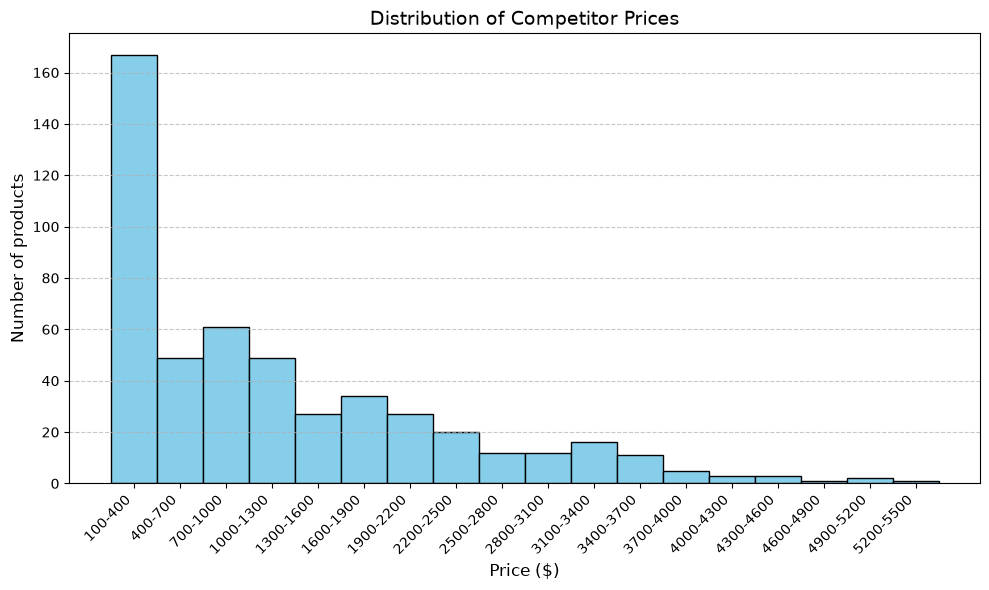

In [6]:
min_price = price.min()
max_price = price.max()

min_bin = np.floor(min_price / 100) * 100 
max_bin = np.ceil(max_price / 100) * 100 
step = 300  

bins = np.arange(min_bin, max_bin + step, step)

plt.figure(figsize=(10, 6))
plt.hist(price, bins=bins, color='skyblue', edgecolor='black')

labels = [f'{int(bins[i])}-{int(bins[i+1])}' for i in range(len(bins)-1)]
plt.xticks(bins[:-1] + step/2, labels, rotation=45, ha='right')

plt.title('Distribution of Competitor Prices', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Number of products', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('price_distribution.png')
plt.show()


#Chart illustrates that the most of laptops of competitors
#are in budget segment (USD100-400), competition in this segment is strongest. 
#Competition in expensive segment (from USD3700 and above) is weakest


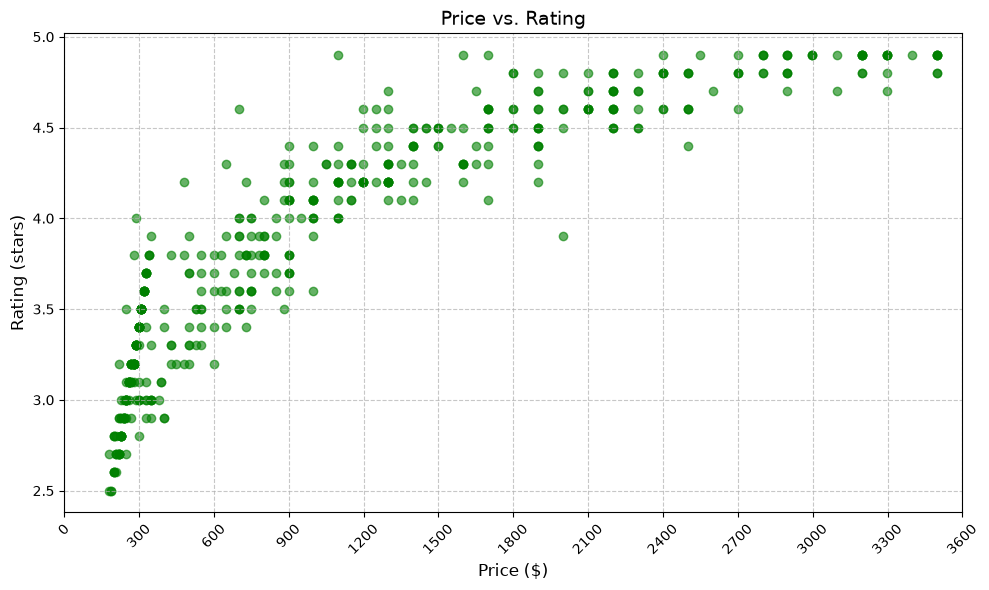

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(price, df['Rating'], color='green', alpha=0.6)


upper_limit = price.quantile(0.95)  
plt.xlim(0, upper_limit)  

step = 300
min_price = price.min()
max_price = upper_limit
min_bin = np.floor(min_price / step) * step
max_bin = np.ceil(max_price / step) * step
xticks = np.arange(min_bin, max_bin + step, step)
plt.xticks(xticks, rotation=45)

plt.yticks(np.arange(2.5, 5.5, 0.5))

plt.title('Price vs. Rating', fontsize=14)
plt.xlabel('Price ($)', fontsize=12)
plt.ylabel('Rating (stars)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('price_vs_rating.png')
plt.show()

#Rating of most of the budget laptops is below 4-4.5
#Expensive laptops almost don't have low rating
#Correelation between price and rating on the market is high
#There is connection between price and quality
#Customers are more satisfied with more expensive and high-quality products

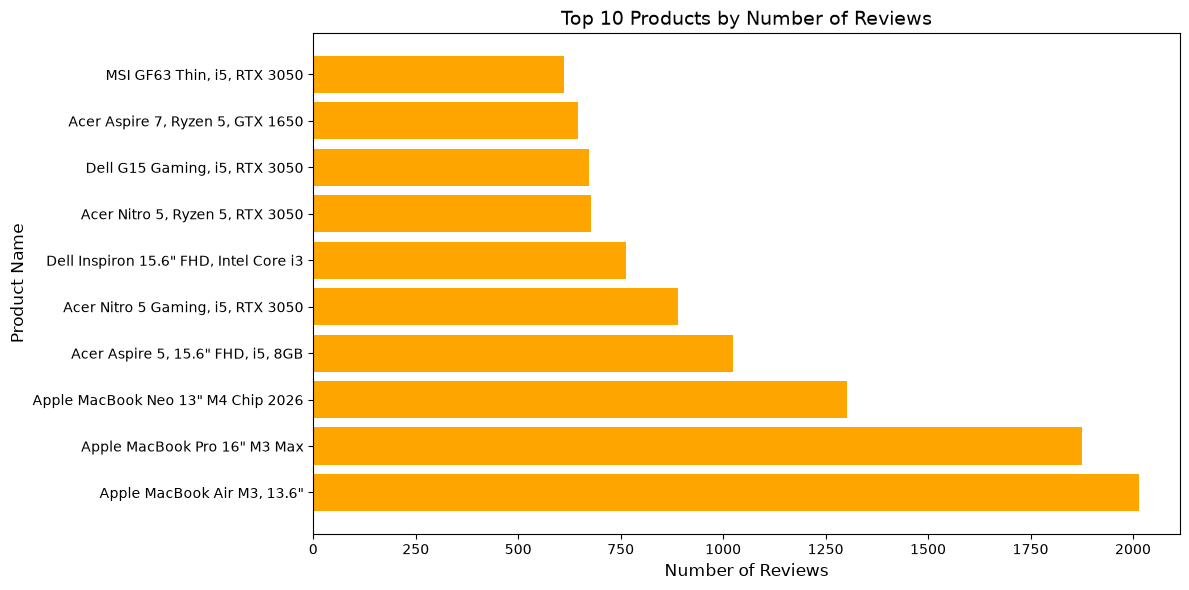

In [8]:
top_10 = df.nlargest(10, 'Reviews')[['Title', 'Reviews']]

plt.figure(figsize=(12, 6))
plt.barh(top_10['Title'], top_10['Reviews'], color='orange')
plt.title('Top 10 Products by Number of Reviews', fontsize=14)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Product Name', fontsize=12)
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()